
# LIMOncello – Deskew và đồng bộ thời gian

Notebook này giải thích **motion compensation (deskew)** và **time synchronization** trong LIMOncello theo kiểu dành cho người mới, nhưng vẫn bám sát logic của code hiện tại.

## Mục tiêu học xong notebook này

- Hiểu vì sao một frame LiDAR bị **méo** khi robot di chuyển trong lúc quét.
- Hiểu LIMOncello lấy **timestamp tuyệt đối cho từng điểm** như thế nào.
- Hiểu **state buffer** của IMU được tạo ra và dùng ra sao.
- Hiểu tại sao `filter_states()` phải lấy **một state ngay trước start time**.
- Hiểu công thức deskew cốt lõi:
  \[
  p_i^{L_\text{ref}} = T_{WL}(t_\text{ref})^{-1}\,T_{WL}(t_i)\,p_i^{L_i}.
  \]
- Hiểu `interpolate_to()` trong LIMOncello **không phải** là slerp/lerp thuần túy, mà là **mini propagation bằng IMU model**.
- Có một bộ hình minh họa để nhìn trực quan timeline, buffer và point-to-frame correction.



## Các mảnh code và tài liệu mà notebook bám theo

Phần giải thích dưới đây nối trực tiếp các file/chức năng sau:

- **Paper LIMOncello**
  - Fig. 2: pipeline tổng thể
  - §III-A: system overview
  - §III-C: forward propagation
- **`src/main.cpp`**
  - `imu_callback(...)`
  - `process_cloud(...)`
- **`include/Core/Cloud.hpp`**
  - `filter_states(...)`
  - `deskew(...)`
  - `voxel_grid(...)`
  - `filter(...)`
- **`include/Utils/PCL.hpp`**
  - `point_time_func()`
  - `get_point_time_comp()`
  - `min_at_front_max_at_back(...)`
- **`include/Core/State.hpp`**
  - `predict(...)`
  - `interpolate_to(...)`

> Ý tưởng lớn của LIMOncello là:
> 1. IMU chạy liên tục và sinh ra một **cửa sổ pose trung gian**.
> 2. Mỗi điểm LiDAR được gắn với **pose đúng timestamp của chính nó**.
> 3. Tất cả điểm sau đó được quy về **một frame tham chiếu chung**, rồi mới đi vào downsampling, residual computation và IESEKF update.


In [1]:

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 120)
np.set_printoptions(precision=4, suppress=True)

def rot2(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s],
                     [s,  c]])

def make_T(x, y, yaw):
    T = np.eye(3)
    T[:2, :2] = rot2(yaw)
    T[:2, 2] = [x, y]
    return T

def inv_T(T):
    R = T[:2, :2]
    t = T[:2, 2]
    Tinv = np.eye(3)
    Tinv[:2, :2] = R.T
    Tinv[:2, 2] = -R.T @ t
    return Tinv

def act(T, p):
    ph = np.r_[p, 1.0]
    qh = T @ ph
    return qh[:2]

print("Notebook setup complete.")


Matplotlib is building the font cache; this may take a moment.


Notebook setup complete.



## 1. Bức tranh lớn: deskew nằm ở đâu trong pipeline?

Trong paper, pipeline của LIMOncello là:

1. **Forward Propagation** bằng IMU  
2. **Motion Compensation / Deskew**
3. **Voxel Grid Downsampling**
4. **Residual Computation**
5. **Iterated State Update**
6. **Point-wise insertion vào i-Octree**

Điểm rất đáng nhớ là LIMOncello deskew **trước** khi downsample và trước khi tạo residual.  
Lý do là nếu cloud còn méo mà đã đi đăng ký vào map, residual point-to-plane sẽ bị “bẩn” ngay từ đầu.

### Ý tưởng vật lý

Trong một scan LiDAR, các điểm **không được đo cùng một thời điểm**.

Nếu robot đang quay hoặc tịnh tiến:

- điểm đầu scan được đo ở pose \(T_{WL}(t_0)\),
- điểm giữa scan ở pose \(T_{WL}(t_m)\),
- điểm cuối scan ở pose \(T_{WL}(t_N)\).

Nếu ta ngây thơ coi cả scan đều ở cùng một pose, những vật thể vốn thẳng trong thế giới sẽ trông **cong / lệch / méo** trong point cloud.



## 2. Timestamp của từng điểm đến từ đâu?

Trong code, `point_time_func()` chọn cách tính **absolute timestamp** của từng điểm tùy loại LiDAR.

Ý tưởng chung:

- Có những cảm biến lưu **offset bên trong scan**.
- Có những cảm biến lưu **timestamp tuyệt đối cho từng điểm**.
- Cờ `sensors.lidar.end_of_sweep` quyết định `sweep_time` là **thời điểm bắt đầu** hay **kết thúc** scan.

### Công thức logic chung

Nếu point field là offset \(\Delta t_i\) trong scan, thì:

- nếu `sweep_time` là **start-of-sweep**:
  \[
  t_i = t_\text{sweep} + \Delta t_i
  \]
- nếu `sweep_time` là **end-of-sweep**:
  \[
  t_i = t_\text{sweep} - \Delta t_i
  \]

Nếu point field đã là timestamp tuyệt đối, code dùng trực tiếp giá trị đó.


In [2]:

rows = [
    ["Ouster", "p.t", "offset nội bộ scan (ns)", "sweep_time ± p.t·1e-9", "Dùng dấu ± theo end_of_sweep"],
    ["Velodyne", "p.time", "offset nội bộ scan (s)", "sweep_time ± p.time", "Dùng dấu ± theo end_of_sweep"],
    ["Hesai", "p.timestamp", "timestamp tuyệt đối (s)", "p.timestamp", "Không cần sweep_time để nội suy theo điểm"],
    ["Livox", "p.timestamp", "timestamp tuyệt đối (ns)", "p.timestamp·1e-9", "Không cần sweep_time để nội suy theo điểm"],
]
df = pd.DataFrame(rows, columns=[
    "LiDAR", "Field trong PointT", "Ý nghĩa", "Absolute time mà code dùng", "Ghi chú"
])
df


,LiDAR,Field trong PointT,Ý nghĩa,Absolute time mà code dùng,Ghi chú
0,Ouster,p.t,offset nội bộ scan (ns),sweep_time ± p.t·1e-9,Dùng dấu ± theo end_of_sweep
1,Velodyne,p.time,offset nội bộ scan (s),sweep_time ± p.time,Dùng dấu ± theo end_of_sweep
2,Hesai,p.timestamp,timestamp tuyệt đối (s),p.timestamp,Không cần sweep_time để nội suy theo điểm
3,Livox,p.timestamp,timestamp tuyệt đối (ns),p.timestamp·1e-9,Không cần sweep_time để nội suy theo điểm



### Hình minh họa: cùng một offset nhưng đổi quy ước start/end của scan sẽ đổi dấu

Điều này giải thích vì sao cấu hình `end_of_sweep` rất quan trọng.
Nếu cấu hình sai, toàn bộ thứ tự thời gian của điểm trong scan sẽ bị đảo.


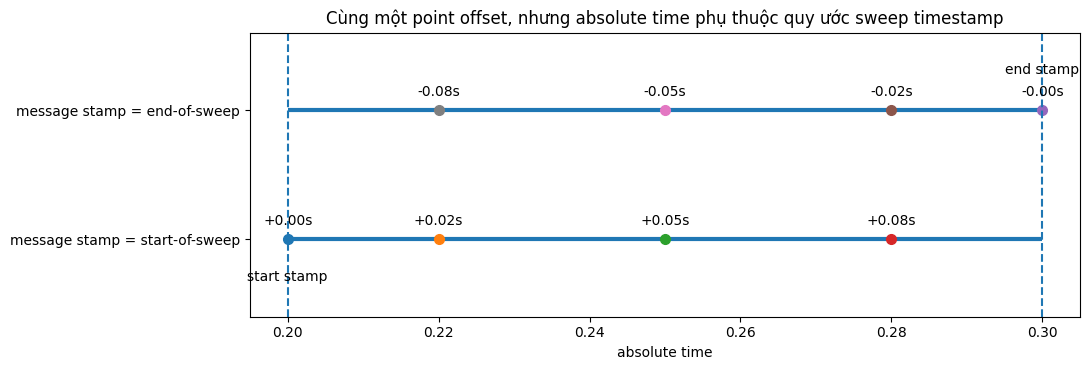

In [3]:

scan_start = 0.20
scan_end = 0.30
offsets = np.array([0.00, 0.02, 0.05, 0.08])

plt.figure(figsize=(11, 3.8))
plt.hlines(1.0, scan_start, scan_end, linewidth=3)
plt.hlines(0.0, scan_start, scan_end, linewidth=3)

for dt in offsets:
    plt.plot(scan_start + dt, 0.0, 'o', markersize=7)
    plt.annotate(f"+{dt:.2f}s", (scan_start + dt, 0.0), xytext=(0, 10), textcoords='offset points', ha='center')

for dt in offsets:
    plt.plot(scan_end - dt, 1.0, 'o', markersize=7)
    plt.annotate(f"-{dt:.2f}s", (scan_end - dt, 1.0), xytext=(0, 10), textcoords='offset points', ha='center')

plt.axvline(scan_start, linestyle='--')
plt.axvline(scan_end, linestyle='--')

plt.text(scan_start, -0.32, "start stamp", ha='center')
plt.text(scan_end,   1.28, "end stamp", ha='center')

plt.yticks([0.0, 1.0], ["message stamp = start-of-sweep", "message stamp = end-of-sweep"])
plt.xlabel("absolute time")
plt.title("Cùng một point offset, nhưng absolute time phụ thuộc quy ước sweep timestamp")
plt.ylim(-0.6, 1.6)
plt.tight_layout()
plt.show()



## 3. `min_at_front_max_at_back()` làm gì?

Đây là một chi tiết rất dễ bị đọc lướt:

- Hàm này **không sort toàn bộ point cloud**.
- Nó chỉ tìm **điểm sớm nhất** và **điểm muộn nhất**, rồi swap chúng ra **đầu** và **cuối** mảng.

Vì thế sau hàm này:

- `cloud->points.front()` chắc chắn là điểm **oldest**
- `cloud->points.back()` chắc chắn là điểm **newest**

Nhưng **các điểm ở giữa vẫn có thể ở thứ tự lộn xộn**.

Code chỉ cần front/back để tính:

\[
t_\text{start} = t(\text{front point}) + \text{offset}
\]
\[
t_\text{end} = t(\text{back point}) + \text{offset}
\]

Nó không cần sort toàn bộ scan vì trong bước deskew, từng điểm sẽ tự truy vấn timestamp của chính nó.



## 4. IMU buffer được xây như thế nào?

Trong `imu_callback(...)`, mỗi IMU mới sẽ:

1. tính \(\Delta t = t_k - t_{k-1}\)
2. gọi `state_.predict(imu, dt)`
3. đẩy state mới vào `state_buffer_` bằng `push_front(state_)`

Nghĩa là buffer gốc có thứ tự:

- **front = state mới nhất**
- **back = state cũ nhất**

Ta có thể hình dung đây là một cuộn lịch sử pose-velocity-bias-gravity được cập nhật ở tốc độ IMU.

### Một điểm cực quan trọng

Mỗi `State` trong buffer không chỉ giữ pose hiện tại, mà còn giữ:

- `stamp`
- `a` = linear acceleration đã dùng ở bước predict
- `w` = angular velocity đã dùng ở bước predict

Chính `a` và `w` này sẽ được tái dùng trong `interpolate_to(...)` để đẩy state từ một IMU stamp lên đúng timestamp của từng điểm LiDAR.


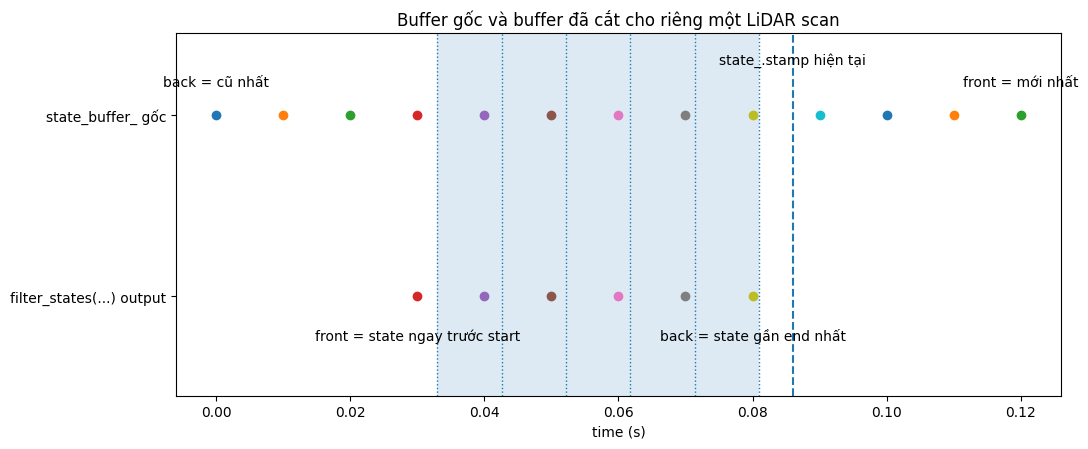

In [4]:

imu_times = np.arange(0.00, 0.125, 0.01)
scan_start = 0.033
scan_end = 0.081
query_times = np.linspace(scan_start, scan_end, 6)
current_state_stamp = 0.086

filtered = imu_times[(imu_times < scan_end) & (imu_times >= scan_start)]
state_before_start = imu_times[imu_times < scan_start][-1]
filtered_with_floor = np.r_[state_before_start, filtered]

plt.figure(figsize=(11, 4.6))

# Raw state buffer (newest at front)
y_raw = 1.0
for t in imu_times:
    plt.plot(t, y_raw, 'o', markersize=6)
plt.text(imu_times[-1], y_raw + 0.16, "front = mới nhất", ha='center')
plt.text(imu_times[0],  y_raw + 0.16, "back = cũ nhất", ha='center')

# Filtered output (oldest -> newest)
y_filt = 0.0
for t in filtered_with_floor:
    plt.plot(t, y_filt, 'o', markersize=6)
plt.text(filtered_with_floor[0], y_filt - 0.24, "front = state ngay trước start", ha='center')
plt.text(filtered_with_floor[-1], y_filt - 0.24, "back = state gần end nhất", ha='center')

for t in query_times:
    plt.axvline(t, linestyle=':', linewidth=1)

plt.axvspan(scan_start, scan_end, alpha=0.15)
plt.axvline(current_state_stamp, linestyle='--')
plt.text(current_state_stamp, 1.28, "state_.stamp hiện tại", ha='center')

plt.yticks([0.0, 1.0], ["filter_states(...) output", "state_buffer_ gốc"])
plt.xlabel("time (s)")
plt.title("Buffer gốc và buffer đã cắt cho riêng một LiDAR scan")
plt.ylim(-0.55, 1.45)
plt.tight_layout()
plt.show()



## 5. Vì sao `filter_states()` phải lấy **một state ngay trước start time**?

Pseudo-logic của `filter_states()` là:

```text
bỏ mọi state mới hơn end
giữ mọi state trong [start, end)
giữ thêm 1 state đầu tiên nhỏ hơn start
```

Mục đích của state “ngay trước start” là để `deskew()` luôn có một **floor state** cho binary search.

Nếu point đầu tiên của scan có timestamp \(t_i \approx t_\text{start}\), ta vẫn muốn có một state \(X(t_k)\) sao cho:

\[
t_k \le t_i
\]

rồi từ đó mới propagate ngắn thêm đến \(t_i\).

### Một điều hay của implementation này

- `state_buffer_` gốc đi theo thứ tự **mới nhất → cũ nhất**
- `filter_states()` lại dùng `push_front`, nên output thành thứ tự **cũ nhất → mới nhất**

Điều đó rất quan trọng, vì `deskew()` dùng `binary_search()` trên buffer đã cắt, và binary search này giả định timestamps **tăng dần**.



## 6. Đồng bộ thời gian: `offset` được tính thế nào?

Trong `process_cloud(...)`, nếu bật `cfg.sensors.time_offset`, code làm:

\[
\text{offset} = \text{state\_.stamp} - t(\text{last point}) - 10^{-4}.
\]

Sau đó:

- nếu `offset > 0`, code ép `offset = 0`
- nên cloud chỉ được **dịch lùi về quá khứ** hoặc giữ nguyên
- code **không bao giờ** đẩy timestamp của điểm sang **tương lai** so với IMU mới nhất

### Trực giác

Mục tiêu của offset này là:

- điểm mới nhất của scan sau khi cộng offset sẽ nằm **ngay trước** state IMU mới nhất
- để deskew không cần extrapolate vượt quá phần IMU đã có

### Lưu ý rất quan trọng

Đây là **căn chỉnh thô theo từng scan**, không phải mô hình đồng hồ tinh vi.

Nó hữu ích khi:

- LiDAR và IMU có cùng time base nhưng có lệch nhỏ ở software
- bạn muốn tránh việc điểm cuối scan “vượt quá” IMU buffer

Nó **không** phải là lời giải hoàn chỉnh cho:

- clock drift dài hạn
- hardware sync sai nặng
- per-sensor latency thay đổi theo thời gian


In [5]:

examples = []
for latest_imu, last_point in [(10.5123, 10.5190), (10.5123, 10.5105)]:
    offset = latest_imu - last_point - 1e-4
    clamped = min(offset, 0.0)
    examples.append([
        latest_imu,
        last_point,
        offset,
        clamped,
        last_point + clamped
    ])

pd.DataFrame(examples, columns=[
    "state_.stamp (IMU latest)",
    "t(last point)",
    "raw offset",
    "offset sau clamp",
    "t(last point) + offset"
])


,state_.stamp (IMU latest),t(last point),raw offset,offset sau clamp,t(last point) + offset
0,10.5123,10.5190,-0.0068,-0.0068,10.5122
1,10.5123,10.5105,0.0017,0.0000,10.5105



Đọc bảng trên:

- Hàng 1: last point đang **đi trước IMU mới nhất**, nên offset âm và cloud bị kéo lùi lại.
- Hàng 2: last point đã **không vượt IMU**, raw offset dương nhỏ nhưng bị clamp về 0 để tránh “nhảy vào tương lai”.



## 7. Công thức deskew cốt lõi trong LIMOncello

Trong code, mỗi point được sửa bằng dòng ý tưởng:

```text
T0 = pose của LiDAR tại thời điểm điểm được đo
TN = pose tham chiếu chung
p_deskew = TN^{-1} * T0 * p_raw
```

### Viết bằng ký hiệu hình học

Gọi:

- \(T_{WL}(t)\): biến đổi từ **LiDAR frame tại thời điểm \(t\)** lên **world**
- \(p_i^{L_i}\): tọa độ điểm thứ \(i\) trong LiDAR frame đúng tại lúc nó được đo
- \(t_i\): timestamp của điểm đó
- \(t_\text{ref}\): thời điểm tham chiếu chung mà ta muốn quy tất cả điểm về

Khi đó:

\[
p_i^W = T_{WL}(t_i)\,p_i^{L_i}
\]

và để viết điểm này trong frame tham chiếu \(L_\text{ref}\):

\[
p_i^{L_\text{ref}} = T_{WL}(t_\text{ref})^{-1}\,T_{WL}(t_i)\,p_i^{L_i}.
\]

Đó chính là thứ code làm với:

\[
T_0 = T_{WL}(t_i), \qquad T_N = T_{WL}(t_\text{ref}).
\]

### Nối sang `State`

Trong LIMOncello:

\[
T_{WL}(t) = T_{WI}(t)\,T_{IL},
\]

trong đó:

- `state.isometry()` đóng vai trò \(T_{WI}(t)\)
- `state.L2I_isometry()` đóng vai trò \(T_{IL}\)

nên trong code:

\[
T_0 = X_0.\text{isometry()} \cdot X_0.\text{L2I\_isometry()}
\]
\[
T_N = \text{state.isometry()} \cdot \text{state.L2I\_isometry()}.
\]

### Một nuance implementation rất đáng nhớ

`TN` trong code là **state hiện tại khi bắt đầu xử lý cloud**.  
Code chỉ chờ để đảm bảo state này **không sớm hơn điểm cuối scan**.

Vì vậy frame tham chiếu thực tế là:

- thường là **scan end** hoặc
- **hơi muộn hơn scan end một chút**

nhưng sẽ **không sớm hơn point cuối**.


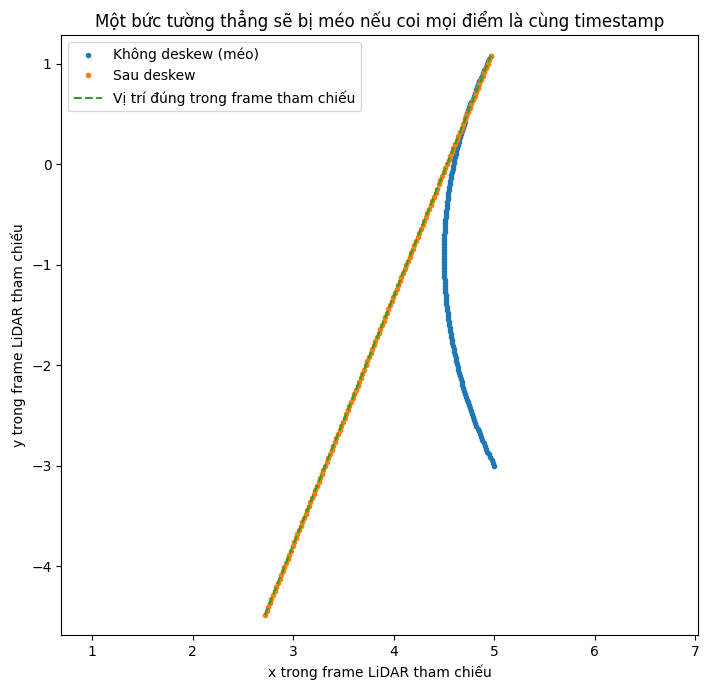

In [6]:

# Simulate a moving LiDAR observing a straight wall.
N = 140
times = np.linspace(0.0, 0.10, N)
wall_y = np.linspace(-3.0, 3.0, N)
world_points = np.c_[np.full(N, 5.0), wall_y]

def pose_traj(t):
    # Moderate forward motion + yaw during one scan
    alpha = t / 0.10
    x = 0.8 * alpha
    y = 0.15 * np.sin(1.2 * alpha)
    yaw = np.deg2rad(22.0) * alpha
    return make_T(x, y, yaw)

T_ref = pose_traj(times[-1])

raw_naive = []
deskewed = []
ideal_ref = []

for t, Pw in zip(times, world_points):
    T_i = pose_traj(t)
    p_local_at_ti = act(inv_T(T_i), Pw)    # what LiDAR really measures at time t_i
    raw_naive.append(p_local_at_ti)        # if we ignore timing and pretend all points are same frame
    deskewed.append(act(inv_T(T_ref) @ T_i, p_local_at_ti))
    ideal_ref.append(act(inv_T(T_ref), Pw))

raw_naive = np.array(raw_naive)
deskewed = np.array(deskewed)
ideal_ref = np.array(ideal_ref)

plt.figure(figsize=(7.2, 7.0))
plt.plot(raw_naive[:, 0], raw_naive[:, 1], '.', label="Không deskew (méo)")
plt.plot(deskewed[:, 0], deskewed[:, 1], '.', label="Sau deskew")
plt.plot(ideal_ref[:, 0], ideal_ref[:, 1], '--', label="Vị trí đúng trong frame tham chiếu")
plt.axis('equal')
plt.xlabel("x trong frame LiDAR tham chiếu")
plt.ylabel("y trong frame LiDAR tham chiếu")
plt.title("Một bức tường thẳng sẽ bị méo nếu coi mọi điểm là cùng timestamp")
plt.legend()
plt.tight_layout()
plt.show()



## 8. `interpolate_to()` có thật sự là “interpolation” không?

Trong `State.hpp`, hàm này là:

\[
X \leftarrow X \boxplus f(a,w)\,\Delta t
\]

với \(\Delta t = t_\text{query} - \text{stamp}\).

Điều này nghĩa là:

- code **không** làm linear interpolation của position
- code **không** làm SLERP giữa hai pose đã biết
- code làm một bước **mini propagation** bằng **motion model của IMU**

Nói dễ nhớ:

> `interpolate_to()` trong LIMOncello gần nghĩa với  
> **“propagate thêm một đoạn ngắn bằng zero-order hold”**  
> hơn là “nội suy hình học giữa hai pose”.

### Zero-order hold ở đây là gì?

Giữa hai mẫu IMU, code giả sử:

- gia tốc \(a\) giữ nguyên
- vận tốc góc \(w\) giữ nguyên

rồi đẩy state từ `buffer[i_f]` tới đúng `t_i`.

Về mặt công thức:

\[
X(t_i) \approx X(t_k) \boxplus f(a_k, w_k)\,(t_i - t_k),
\qquad t_k \le t_i < t_{k+1}.
\]

### Một chi tiết dễ bỏ sót

`interpolate_to()` **không cập nhật `stamp`** trong object tạm.

Điều này ổn vì trong `deskew()`:

- code copy một state tạm `X0 = buffer[i_f]`
- gọi `X0.interpolate_to(...)` đúng **một lần**
- lấy pose rồi bỏ object tạm đó đi

Nếu bạn tái dùng cùng object tạm nhiều lần liên tiếp, bạn sẽ phải cực kỳ cẩn thận vì `stamp` không được tiến lên cùng lúc với `X`.


In [7]:

imu_stamps = np.array([0.000, 0.005, 0.010, 0.015])
query = 0.0072

floor_idx = np.where(imu_stamps <= query)[0][-1]
t_floor = imu_stamps[floor_idx]
dt = query - t_floor

pd.DataFrame({
    "IMU stamps (s)": imu_stamps,
    "Có <= query?": imu_stamps <= query
}), t_floor, dt


(   IMU stamps (s)  Có <= query?
 0           0.000          True
 1           0.005          True
 2           0.010         False
 3           0.015         False,
 np.float64(0.005),
 np.float64(0.0021999999999999997))


Đọc ví dụ trên:

- point có timestamp \(7.2\) ms
- floor state nằm ở \(5.0\) ms
- `interpolate_to()` sẽ propagate thêm \(2.2\) ms bằng cặp \((a,w)\) đã lưu trong state tại \(5.0\) ms

Đây chính là lý do `filter_states()` phải luôn giữ một state ngay trước `start_stamp`.



## 9. Đọc code theo đúng chiều callback

### 9.1. Nhánh IMU

Pseudo-code của `imu_callback(...)`:

```text
imu = fromROS(msg)
dt = imu.stamp - prev_imu.stamp
imu.lin_accel = sm * imu.lin_accel
state_.predict(imu, dt)
state_buffer_.push_front(state_)
notify lidar thread
```

Nhánh này có 2 nhiệm vụ:

1. luôn giữ `state_` là **IMU-propagated state mới nhất**
2. luôn giữ `state_buffer_` là **lịch sử state đủ dày** để LiDAR có thể deskew từng điểm

### 9.2. Nhánh LiDAR

Pseudo-code rút gọn của `process_cloud(...)`:

```text
raw = producer()
min_at_front_max_at_back(raw)

start_stamp = point_time(front) + offset
end_stamp   = point_time(back)  + offset

đợi cho đến khi buffer đã propagate ít nhất tới end_stamp
interpolated = filter_states(state_buffer_, start_stamp, end_stamp)

deskewed = deskew(raw, state_, interpolated, offset, sweep_time)
downsampled = voxel_grid(deskewed)
filtered = filter(downsampled, ...)
state_.update(filtered, ioctree_)
```

### Ý tưởng then chốt

LiDAR thread **không tự tích phân IMU**.  
Nó chỉ:

- lấy raw cloud,
- hỏi “điểm nào được đo lúc nào?”,
- rồi mượn **cửa sổ state IMU đã được tích phân sẵn** để quy toàn bộ điểm về cùng một frame.



## 10. `deskew()` hoạt động thế nào từng điểm một?

Pseudo-code thực tế của `deskew()` là:

```text
for each point k:
    t_k = point_time(point_k, sweep_time) + offset
    i_f = binary_search(t_k)          # floor state
    X0  = buffer[i_f]                 # copy
    X0.interpolate_to(t_k)            # mini propagation tới đúng timestamp của point
    T0  = T_WL(t_k)
    TN  = T_WL(t_ref)
    p_k = TN^{-1} * T0 * p_k
```

### Vì sao cần `binary_search`?

Vì `buffer` sau khi qua `filter_states()` đã có timestamps tăng dần:

\[
t_0 \le t_1 \le \dots \le t_M
\]

Nên với mỗi point time \(t_k\), ta chỉ cần tìm floor index nhanh:

\[
i_f = \max \{ i \mid t_i \le t_k \}.
\]

### Tại sao không tìm `ceil` rồi nội suy giữa hai state?

Vì implementation hiện tại chọn một cách rất “IMU-centric”:

- lấy state gần nhất **không muộn hơn** point time
- dùng chính motion model của hệ để đẩy tới point time

Tức là “interpolation” ở đây thực chất là **short-time propagation**.



## 11. Những lỗi hay gặp khi deskew/time sync bị sai

### 11.1. Sai `end_of_sweep`
Dấu của offset bên trong scan bị đảo.  
Hậu quả:

- điểm đầu scan bị coi thành điểm cuối
- hướng méo của cloud sẽ rất “lạ”
- residual point-to-plane tăng rõ

### 11.2. Sai đơn vị timestamp point field
Ví dụ:

- đáng lẽ nanoseconds nhưng lại coi là seconds
- hoặc timestamp tuyệt đối nhưng lại xử lý như offset trong scan

Hậu quả là thời gian point nhảy lung tung hàng chục ms hay hàng giây.

### 11.3. Buffer IMU chưa phủ hết scan
Nếu `state_buffer_.front().stamp < end_stamp`, code sẽ phải chờ.
Nếu buffer quá ngắn hoặc IMU tới không đều, bạn sẽ thiếu pose để deskew.

### 11.4. Tin rằng `min_at_front_max_at_back()` đã sort xong cloud
Không đúng.  
Hàm này chỉ kéo **oldest point** ra đầu và **newest point** ra cuối.

### 11.5. Nghĩ rằng `interpolate_to()` là pose lerp/slerp
Không đúng.  
Nó là một bước **propagation bằng IMU model**.

### 11.6. Quên rằng `offset` chỉ là căn chỉnh thô
Nếu hai sensor không thật sự chung time base hoặc có drift nặng, một offset theo từng scan sẽ không cứu được.



## 12. Checklist debug thực tế

Khi bạn chạy LIMOncello và nghi ngờ deskew/sync có vấn đề, hãy kiểm tra lần lượt:

1. **Point time có hợp lý không?**  
   In ra `point_time(front)`, `point_time(back)` và vài điểm giữa scan.

2. **`start_stamp <= end_stamp` có đúng không?**  
   Nếu không đúng, gần như chắc chắn cờ `end_of_sweep` hoặc đơn vị time field đang sai.

3. **`state_.stamp - end_stamp` có hơi dương không?**  
   Nó nên dương nhỏ hoặc gần 0, chứ không nên âm lớn.

4. **Cloud debug `raw` vs `deskewed` khác nhau có hợp lý không?**  
   Khi robot quay nhanh, sự khác biệt phải thấy được.

5. **Nếu bật `time_offset`, offset có quá lớn không?**  
   Nếu mỗi scan đều phải kéo lùi rất nhiều ms, khả năng cao đang có lỗi sync thật sự.

6. **Buffer có đủ dày không?**  
   Nếu IMU rate thấp hoặc callback bị nghẽn, deskew sẽ rất yếu.

7. **Reference frame của deskew là gì?**  
   Trong implementation hiện tại, nó là **state mới nhất đang có khi xử lý cloud**, không phải một pose “ma thuật” nào khác.



## 13. Tóm tắt một trang

### Bạn chỉ cần nhớ 6 ý này

**(1)** Mỗi điểm LiDAR có timestamp riêng, không phải cả scan cùng một thời điểm.

**(2)** `point_time_func()` biến thông tin timestamp/offset của từng điểm thành **absolute time**.

**(3)** IMU callback liên tục chạy `predict()` và đẩy state mới vào `state_buffer_`.

**(4)** `filter_states()` cắt buffer theo cửa sổ scan và giữ thêm **một state ngay trước start**.

**(5)** `interpolate_to()` không phải pose lerp; nó là **zero-order hold propagation** bằng IMU model.

**(6)** Deskew thật sự chỉ là:
\[
p_i^{L_\text{ref}} = T_{WL}(t_\text{ref})^{-1}\,T_{WL}(t_i)\,p_i^{L_i}.
\]

---

## 14. Câu thần chú để nhớ

> **IMU tạo ra một dải pose theo thời gian.**  
> **Mỗi điểm LiDAR mượn đúng pose của thời điểm nó được đo.**  
> **Sau đó tất cả điểm được kéo về cùng một frame tham chiếu.**

Nếu bạn đã nắm được câu đó, bạn đã hiểu phần cốt lõi của deskew trong LIMOncello.

---

## 15. Tham khảo để đọc tiếp

- Paper LIMOncello: phần pipeline tổng thể, prediction và motion compensation
- `src/main.cpp`: `imu_callback(...)`, `process_cloud(...)`
- `include/Core/Cloud.hpp`: `filter_states(...)`, `deskew(...)`
- `include/Utils/PCL.hpp`: `point_time_func()`, `min_at_front_max_at_back(...)`
- `include/Core/State.hpp`: `predict(...)`, `interpolate_to(...)`

Notebook này cố ý giải thích theo **luồng dữ liệu thực tế** thay vì chỉ chép công thức.
